# Signal-Space Image Generation - Part 2: Generation and Evaluation

Run this after Part 1. It rebuilds the model definitions, loads a saved checkpoint, then runs prompt generation, teacher-forced visualization, and held-out evaluation without retraining.


## 1. Environment setup

In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os

# Works on Kaggle, Colab, and local Jupyter. On Kaggle, add HF_TOKEN as a secret.
# On Colab, either set os.environ["HF_TOKEN"] or add HF_TOKEN to Colab secrets.
if os.path.isdir("/kaggle/working"):
    WORK_DIR = "/kaggle/working"
elif os.path.isdir("/content"):
    WORK_DIR = "/content"
else:
    WORK_DIR = os.getcwd()

hf_token = os.environ.get("HF_TOKEN")
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN") or hf_token
except Exception:
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN") or hf_token
    except Exception:
        pass

if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    print(f"HF_TOKEN set, WORK_DIR={WORK_DIR}")
else:
    print(f"HF_TOKEN not set; continuing without it. WORK_DIR={WORK_DIR}")


HF_TOKEN set, WORK_DIR=/kaggle/working


In [3]:
import math
from dataclasses import dataclass, field
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

## 2. Configuration

Single source of truth for all hyperparameters. Image size is reduced to 32
because sequence length scales roughly as `H * W * samples_per_pixel`, and a
~2,200 step sequence is the practical limit for a transformer on T4 memory
without gradient checkpointing. Increase `image_size` only after the pipeline
produces reasonable results at 32.

In [4]:
@dataclass
class Config:
    # Image and scan geometry
    image_size: int = 32
    channels: int = 3
    samples_per_pixel: int = 2
    flyback_frac: float = 0.08

    # Renderer
    beam_sigma: float = 0.75

    # Conditioning
    clip_dim: int = 512
    cond_dim: int = 256

    # Transformer
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 6
    ff_mult: int = 4
    dropout: float = 0.1

    # Output head (discretized mixture of logistics)
    n_mixtures: int = 5

    # Training
    batch_size: int = 24
    epochs: int = 30
    lr: float = 3e-4
    weight_decay: float = 1e-2
    grad_clip: float = 1.0
    warmup_steps: int = 500

    # Scheduled sampling: probability of feeding the model's own prediction
    # instead of the ground-truth at each step. Linearly annealed from 0 to
    # ss_max over training.
    ss_max: float = 0.25

    # Ablation toggles. Flip these to produce matched comparisons.
    use_path_pos_enc: bool = True
    use_seq_pos_enc: bool = True
    use_flyback_mask: bool = True
    use_film: bool = True

    seed: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
print(f"device: {cfg.device}")

device: cuda


## 3. Scan path

The raster scan visits every row left-to-right at `samples_per_pixel`
resolution, then flies back across the row (beam off) before starting the
next row. Flyback positions are included in the sequence so that the
transformer sees them as genuine time steps, but they are masked from the
reconstruction loss and contribute zero energy in the renderer.

In [5]:
def generate_raster_path(w, h, samples_per_pixel, flyback_frac):
    samples_per_row = w * samples_per_pixel
    flyback_samples = max(int(samples_per_row * flyback_frac), 1)

    xs, ys, on = [], [], []
    for row in range(h):
        y = row + 0.5
        for i in range(samples_per_row):
            x = (i / max(samples_per_row - 1, 1)) * (w - 1)
            xs.append(x); ys.append(y); on.append(True)
        for i in range(flyback_samples):
            t = (i + 1) / flyback_samples
            x = (1 - t) * (w - 1)
            xs.append(x); ys.append(y); on.append(False)

    path = np.stack([np.array(xs, np.float32), np.array(ys, np.float32)], axis=1)
    beam_on = np.array(on, dtype=bool)
    return path, beam_on


path_np, beam_on_np = generate_raster_path(
    cfg.image_size, cfg.image_size, cfg.samples_per_pixel, cfg.flyback_frac
)
SEQ_LEN = len(path_np)
print(f"sequence length: {SEQ_LEN}")
print(f"active fraction: {beam_on_np.mean():.3f}")

sequence length: 2208
active fraction: 0.928


## 4. Differentiable CRT renderer

Each signal sample deposits a Gaussian spot of width `beam_sigma` at its path
position, weighted by its intensity. The output image is the sum of all spots.

Two changes from the previous renderer:

- **Fixed normalization.** The previous version divided by a per-image max,
  which is non-smooth (only the argmax pixel contributes gradient) and breaks
  the correspondence between signal magnitude and output brightness. Here we
  divide by a fixed constant `renderer_gain`, computed once from the expected
  kernel overlap at the given beam sigma and sampling rate. This keeps the
  mapping linear and all positions contribute gradient.
- **Flyback masking is enforced at the renderer, not just in the loss.** A
  flyback sample with any predicted intensity would still deposit energy
  under the previous setup; here we multiply by the `beam_on` mask inside
  `forward`.

In [6]:
class CRTRenderer(nn.Module):
    def __init__(self, path: np.ndarray, beam_on: np.ndarray,
                 image_size: int, sigma: float):
        super().__init__()
        self.image_size = image_size
        self.sigma = sigma

        self.register_buffer("path_x", torch.from_numpy(path[:, 0]).float())
        self.register_buffer("path_y", torch.from_numpy(path[:, 1]).float())
        self.register_buffer(
            "beam_on_f", torch.from_numpy(beam_on.astype(np.float32))
        )

        ys, xs = torch.meshgrid(
            torch.arange(image_size, dtype=torch.float32),
            torch.arange(image_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("grid_x", xs)
        self.register_buffer("grid_y", ys)

        # Fixed gain: approximate overlap of Gaussian kernels at the active
        # sample density along a row. This keeps a unit signal value on a
        # fully-lit row mapping to roughly unit image brightness.
        samples_per_pixel = beam_on.sum() / image_size ** 2
        gain = samples_per_pixel * 2.0 * math.pi * sigma * sigma
        self.register_buffer("gain", torch.tensor(max(gain, 1e-3)))

    def forward(self, signal: torch.Tensor) -> torch.Tensor:
        # signal: (B, N, C) with values in [0, 1]
        b, n, c = signal.shape
        h = w = self.image_size

        sig = signal * self.beam_on_f.view(1, n, 1)

        dx = self.grid_x.view(1, h, w) - self.path_x.view(n, 1, 1)
        dy = self.grid_y.view(1, h, w) - self.path_y.view(n, 1, 1)
        weights = torch.exp(-(dx * dx + dy * dy) / (2.0 * self.sigma ** 2))

        img = torch.einsum("bnc,nhw->bchw", sig, weights) / self.gain
        return img.clamp(0.0, 1.0)


renderer = CRTRenderer(path_np, beam_on_np, cfg.image_size, cfg.beam_sigma).to(cfg.device)

## 5. Image to signal conversion

Bilinear sampling of the image at each path position, with flyback samples
zeroed. Cached per-image during dataset construction so the scan conversion
does not run every training step.

In [7]:
def image_to_signal(image: torch.Tensor, path_t: torch.Tensor,
                    beam_on_t: torch.Tensor) -> torch.Tensor:
    # image: (C, H, W), path_t: (N, 2), beam_on_t: (N,)
    c, h, w = image.shape
    xs = 2.0 * path_t[:, 0] / (w - 1) - 1.0
    ys = 2.0 * path_t[:, 1] / (h - 1) - 1.0
    grid = torch.stack([xs, ys], dim=-1).view(1, -1, 1, 2)
    sampled = F.grid_sample(
        image.unsqueeze(0), grid, mode="bilinear", align_corners=True
    )
    signal = sampled.squeeze(-1).squeeze(0).T  # (N, C)
    signal = signal.clamp(0.0, 1.0)
    signal = signal * beam_on_t.unsqueeze(-1)
    return signal

## 6. Dataset

Oxford Flowers 102 with per-class captions. Signals are computed once at
initialization and stored in memory; for 8k images at ~2,200 steps with 3
channels in float16 this is roughly 100 MB. Raise `image_size` or drop the
cache if you run out of RAM.

In [8]:
FLOWER_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle", "snapdragon",
    "colts foot", "king protea", "spear thistle", "yellow iris",
    "globe-flower", "purple coneflower", "peruvian lily", "balloon flower",
    "giant white arum lily", "fire lily", "pincushion flower", "fritillary",
    "red ginger", "grape hyacinth", "corn poppy", "prince of wales feathers",
    "stemless gentian", "artichoke", "sweet william", "carnation",
    "garden phlox", "love in the mist", "mexican aster", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort", "siam tulip",
    "lenten rose", "barbeton daisy", "daffodil", "sword lily", "poinsettia",
    "bolero deep blue", "wallflower", "marigold", "buttercup", "oxeye daisy",
    "common dandelion", "petunia", "wild pansy", "primula", "sunflower",
    "pelargonium", "bishop of llandaff", "gaura", "geranium", "orange dahlia",
    "pink-yellow dahlia", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy", "osteospermum",
    "spring crocus", "bearded iris", "windflower", "tree poppy", "gazania",
    "azalea", "water lily", "rose", "thorn apple", "morning glory",
    "passion flower", "lotus", "toad lily", "anthurium", "frangipani",
    "clematis", "hibiscus", "columbine", "desert-rose", "tree mallow",
    "magnolia", "cyclamen", "watercress", "canna lily", "hippeastrum",
    "bee balm", "ball moss", "foxglove", "bougainvillea", "camellia",
    "mallow", "mexican petunia", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily",
]


class FlowerSignalDataset(Dataset):
    def __init__(self, hf_split, path_np, beam_on_np, image_size, label_names):
        from torchvision import transforms
        self.label_names = label_names
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

        path_t = torch.from_numpy(path_np)
        beam_on_t = torch.from_numpy(beam_on_np.astype(np.float32))

        self.signals = []
        self.captions = []
        for sample in hf_split:
            img = self.transform(sample["image"].convert("RGB"))
            sig = image_to_signal(img, path_t, beam_on_t)
            self.signals.append(sig.half())
            label = sample.get("label", 0)
            name = label_names[label] if label < len(label_names) else "flower"
            self.captions.append(f"a photo of a {name}")

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        return self.signals[idx].float(), self.captions[idx]

In [9]:
from datasets import load_dataset
hf = load_dataset("nelorth/oxford-flowers", split="train")
print(f"images: {len(hf)}")

dataset = FlowerSignalDataset(
    hf, path_np, beam_on_np, cfg.image_size, FLOWER_NAMES
)
print(f"cached signals: {len(dataset)}")

sig0, cap0 = dataset[0]
print(f"signal shape: {tuple(sig0.shape)}  caption: {cap0}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-12de94e121bdbe(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

data/test-00000-of-00001-96eeec628415add(…):   0%|          | 0.00/43.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1020 [00:00<?, ? examples/s]

images: 7169
cached signals: 7169
signal shape: (2208, 3)  caption: a photo of a pink primrose


In [10]:
hf_test = load_dataset("nelorth/oxford-flowers", split="test")
test_dataset = FlowerSignalDataset(
    hf_test, path_np, beam_on_np, cfg.image_size, FLOWER_NAMES
)
print(f"test images: {len(test_dataset)}")

test images: 1020


## 7. CLIP text encoder

In [11]:
import clip


def load_clip(device):
    model, _ = clip.load("ViT-B/32", device=device)
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    return model


@torch.no_grad()
def encode_texts(clip_model, texts, device):
    tokens = clip.tokenize(texts, truncate=True).to(device)
    feats = clip_model.encode_text(tokens).float()
    return feats / feats.norm(dim=-1, keepdim=True)


clip_model = load_clip(cfg.device)

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 273MiB/s]


## 8. Positional encodings

Two encodings are concatenated to every token:

- **1D sequence index encoding.** Standard sinusoidal encoding over the
  sequence position. Gives the model "how far along the scan am I."
- **2D path position encoding.** Sinusoidal encoding of the (x, y) spatial
  coordinate of each sample. Gives the model "where on the screen is this
  sample." This is the piece most missing from the previous implementation
  and the reason it could not recover 2D spatial structure.

Both encodings are precomputed once and registered as buffers.

In [12]:
def sinusoidal_1d(n_positions: int, dim: int) -> torch.Tensor:
    pe = torch.zeros(n_positions, dim)
    position = torch.arange(n_positions, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, dtype=torch.float32) * -(math.log(10000.0) / dim)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


def sinusoidal_2d(coords: torch.Tensor, dim: int,
                  max_coord: float) -> torch.Tensor:
    # coords: (N, 2) in [0, max_coord]
    half = dim // 2
    div_term = torch.exp(
        torch.arange(0, half, 2, dtype=torch.float32) * -(math.log(10000.0) / half)
    )
    x = coords[:, 0:1] / max_coord * math.pi * 2 * (max_coord / 2)
    y = coords[:, 1:2] / max_coord * math.pi * 2 * (max_coord / 2)

    pe = torch.zeros(coords.shape[0], dim)
    pe[:, 0:half:2] = torch.sin(x * div_term)
    pe[:, 1:half:2] = torch.cos(x * div_term)
    pe[:, half::2] = torch.sin(y * div_term)
    pe[:, half + 1::2] = torch.cos(y * div_term)
    return pe

## 9. FiLM conditioning

CLIP features are projected to a `(gamma, beta)` pair per transformer block
and applied as feature-wise affine modulation. This is a stronger conditioning
pathway than concatenation because the conditioning signal is refreshed at
every block and cannot be drowned out by the recurrent dynamics.

In [13]:
class FiLM(nn.Module):
    def __init__(self, cond_dim: int, feature_dim: int):
        super().__init__()
        self.to_scale_shift = nn.Linear(cond_dim, feature_dim * 2)
        nn.init.zeros_(self.to_scale_shift.weight)
        nn.init.zeros_(self.to_scale_shift.bias)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        # x: (B, N, D), cond: (B, cond_dim)
        scale, shift = self.to_scale_shift(cond).chunk(2, dim=-1)
        return x * (1.0 + scale.unsqueeze(1)) + shift.unsqueeze(1)

## 10. Causal transformer block

Pre-norm transformer with causal self-attention and FiLM conditioning applied
after each sublayer's residual. Using PyTorch's built-in
`scaled_dot_product_attention` so it can dispatch to FlashAttention on T4.

In [14]:
class CausalBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, ff_mult: int,
                 cond_dim: int, dropout: float, use_film: bool):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.use_film = use_film

        self.norm1 = nn.LayerNorm(d_model)
        self.qkv = nn.Linear(d_model, d_model * 3, bias=False)
        self.attn_out = nn.Linear(d_model, d_model)

        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mult),
            nn.GELU(),
            nn.Linear(d_model * ff_mult, d_model),
        )

        self.dropout = nn.Dropout(dropout)

        if use_film:
            self.film1 = FiLM(cond_dim, d_model)
            self.film2 = FiLM(cond_dim, d_model)

    def _attn(self, x: torch.Tensor) -> torch.Tensor:
        b, n, d = x.shape
        qkv = self.qkv(x).view(b, n, 3, self.n_heads, self.d_head)
        q, k, v = qkv.unbind(dim=2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        out = out.transpose(1, 2).contiguous().view(b, n, d)
        return self.attn_out(out)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        h = x + self.dropout(self._attn(self.norm1(x)))
        if self.use_film:
            h = self.film1(h, cond)
        h = h + self.dropout(self.ff(self.norm2(h)))
        if self.use_film:
            h = self.film2(h, cond)
        return h

## 11. Discretized mixture of logistics output head

For each step the model predicts, per channel, a mixture of `K` logistic
distributions. Target signals are quantized to 256 bins and the negative
log-likelihood of the quantized target is the training loss.

This replaces MSE regression. Benefits:

- Produces a real probability distribution, so temperature sampling and
  nucleus sampling are well-defined operations rather than post-hoc noise.
- Handles multimodal output (e.g., either red petal or green leaf at a given
  position) without averaging to a muddy mean.
- Matches the PixelCNN++ convention so comparison numbers transfer.

The formulation here treats RGB channels as conditionally independent given
the mixture assignment, which is the standard simplified variant. Full
PixelCNN++ also learns linear inter-channel coefficients; that can be added
without changing the rest of the pipeline.

In [15]:
class DMoLHead(nn.Module):
    def __init__(self, d_model: int, channels: int, n_mix: int):
        super().__init__()
        self.channels = channels
        self.n_mix = n_mix
        # Per step: n_mix logits + channels * n_mix * 2 (mean, log_scale)
        self.out = nn.Linear(d_model, n_mix + channels * n_mix * 2)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        return self.out(h)

    def _split(self, params: torch.Tensor):
        k = self.n_mix
        c = self.channels
        logit_probs = params[..., :k]
        rest = params[..., k:].view(*params.shape[:-1], c, k, 2)
        means = rest[..., 0]
        log_scales = rest[..., 1].clamp(min=-7.0)
        return logit_probs, means, log_scales

    def nll(self, params: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # target in [0, 1]; quantized to 256 bins.
        logit_probs, means, log_scales = self._split(params)
        t = target.unsqueeze(-1)  # (..., C, 1) broadcast to mixtures
        inv_s = torch.exp(-log_scales)
        centered = t - means
        bin_half = 0.5 / 255.0
        plus_in = inv_s * (centered + bin_half)
        min_in = inv_s * (centered - bin_half)
        cdf_plus = torch.sigmoid(plus_in)
        cdf_min = torch.sigmoid(min_in)
        # Edge handling for exact 0 and 1 bins.
        log_cdf_plus = plus_in - F.softplus(plus_in)
        log_one_minus_cdf_min = -F.softplus(min_in)
        prob = cdf_plus - cdf_min
        log_prob_mid = torch.log(prob.clamp(min=1e-12))

        log_probs = torch.where(
            target.unsqueeze(-1) < 1e-3,
            log_cdf_plus,
            torch.where(
                target.unsqueeze(-1) > 1.0 - 1e-3,
                log_one_minus_cdf_min,
                log_prob_mid,
            ),
        )
        # Sum over channels, then log-mix.
        log_probs = log_probs.sum(dim=-2)  # (..., K)
        log_mix = F.log_softmax(logit_probs, dim=-1)
        return -torch.logsumexp(log_mix + log_probs, dim=-1)

    @torch.no_grad()
    def sample(self, params: torch.Tensor, temperature: float = 1.0,
               top_p: float = 1.0) -> torch.Tensor:
        logit_probs, means, log_scales = self._split(params)

        if temperature <= 0:
            k_idx = logit_probs.argmax(dim=-1)
        else:
            scaled = logit_probs / max(temperature, 1e-6)
            probs = F.softmax(scaled, dim=-1)
            if top_p < 1.0:
                sorted_p, sorted_i = probs.sort(dim=-1, descending=True)
                cum = sorted_p.cumsum(dim=-1)
                mask = cum - sorted_p > top_p
                sorted_p = sorted_p.masked_fill(mask, 0.0)
                sorted_p = sorted_p / sorted_p.sum(dim=-1, keepdim=True)
                probs = torch.zeros_like(probs).scatter_(-1, sorted_i, sorted_p)
            k_idx = torch.distributions.Categorical(probs=probs).sample()

        k_idx_exp = k_idx.unsqueeze(-1).unsqueeze(-1).expand(
            *k_idx.shape, self.channels, 1
        )
        chosen_mean = means.gather(-1, k_idx_exp).squeeze(-1)
        chosen_log_s = log_scales.gather(-1, k_idx_exp).squeeze(-1)

        if temperature <= 0:
            sample = chosen_mean
        else:
            u = torch.rand_like(chosen_mean).clamp(1e-5, 1.0 - 1e-5)
            sample = chosen_mean + torch.exp(chosen_log_s) * (
                torch.log(u) - torch.log1p(-u)
            ) * temperature

        return sample.clamp(0.0, 1.0)

## 12. Full model

Signal-space transformer:

- Input embedding projects RGB to `d_model`.
- Sequence + path positional encodings added (both optional for ablation).
- Flyback mask feature concatenated as an extra input channel when enabled.
- Six causal blocks with FiLM conditioning.
- DMoL head produces the per-step mixture parameters.

In [16]:
class SignalTransformer(nn.Module):
    def __init__(self, cfg: Config, path: np.ndarray, beam_on: np.ndarray):
        super().__init__()
        self.cfg = cfg
        seq_len = len(path)
        input_ch = cfg.channels + (1 if cfg.use_flyback_mask else 0)

        self.input_proj = nn.Linear(input_ch, cfg.d_model)
        self.cond_proj = nn.Sequential(
            nn.Linear(cfg.clip_dim, cfg.cond_dim),
            nn.GELU(),
            nn.Linear(cfg.cond_dim, cfg.cond_dim),
        )

        seq_pe = sinusoidal_1d(seq_len, cfg.d_model)
        self.register_buffer("seq_pe", seq_pe)

        path_t = torch.from_numpy(path)
        path_pe = sinusoidal_2d(path_t, cfg.d_model, max_coord=cfg.image_size - 1)
        self.register_buffer("path_pe", path_pe)

        self.register_buffer("beam_on_f",
                             torch.from_numpy(beam_on.astype(np.float32)))

        self.blocks = nn.ModuleList([
            CausalBlock(cfg.d_model, cfg.n_heads, cfg.ff_mult,
                        cfg.cond_dim, cfg.dropout, cfg.use_film)
            for _ in range(cfg.n_layers)
        ])
        self.norm_out = nn.LayerNorm(cfg.d_model)
        self.head = DMoLHead(cfg.d_model, cfg.channels, cfg.n_mixtures)

    def _prepare_input(self, signal_prev: torch.Tensor) -> torch.Tensor:
        if self.cfg.use_flyback_mask:
            mask = self.beam_on_f[: signal_prev.size(1)]
            mask = mask.view(1, -1, 1).expand(signal_prev.size(0), -1, 1)
            return torch.cat([signal_prev, mask], dim=-1)
        return signal_prev

    def forward(self, shifted_signal: torch.Tensor,
                clip_emb: torch.Tensor) -> torch.Tensor:
        # shifted_signal: (B, N, C). First position is a learned start token.
        x = self._prepare_input(shifted_signal)
        b, n, _ = x.shape
        h = self.input_proj(x)

        if self.cfg.use_seq_pos_enc:
            h = h + self.seq_pe[:n].unsqueeze(0)
        if self.cfg.use_path_pos_enc:
            h = h + self.path_pe[:n].unsqueeze(0)

        cond = self.cond_proj(clip_emb)
        for block in self.blocks:
            h = block(h, cond)
        h = self.norm_out(h)
        return self.head(h)

    @torch.no_grad()
    def generate(self, clip_emb: torch.Tensor, n_steps: int,
                 temperature: float = 1.0, top_p: float = 1.0) -> torch.Tensor:
        device = clip_emb.device
        b = clip_emb.size(0)
        c = self.cfg.channels

        cond = self.cond_proj(clip_emb)
        generated = torch.zeros(b, 0, c, device=device)
        prev = torch.zeros(b, 1, c, device=device)

        # Precompute once.
        seq_pe = self.seq_pe.unsqueeze(0)
        path_pe = self.path_pe.unsqueeze(0)

        # Incremental generation: recomputes full forward per step, O(N^2)
        # total attention work. A production version would maintain a KV
        # cache to reduce this to O(N).
        for i in range(n_steps):
            inp = torch.cat([prev, generated], dim=1) if generated.size(1) else prev
            x = self._prepare_input(inp)
            h = self.input_proj(x)
            if self.cfg.use_seq_pos_enc:
                h = h + seq_pe[:, : h.size(1)]
            if self.cfg.use_path_pos_enc:
                h = h + path_pe[:, : h.size(1)]
            for block in self.blocks:
                h = block(h, cond)
            h = self.norm_out(h)
            params = self.head(h[:, -1:, :])

            next_sample = self.head.sample(params, temperature=temperature,
                                           top_p=top_p)
            # Zero flyback positions explicitly.
            if self.cfg.use_flyback_mask and not bool(self.beam_on_f[i]):
                next_sample = torch.zeros_like(next_sample)
            generated = torch.cat([generated, next_sample], dim=1)

        return generated

## 13. Training

- AdamW with warmup-then-cosine schedule.
- Scheduled sampling: with probability `p_ss` replace the ground-truth token
  at position `t` with a sample from the model's prediction at `t-1`. `p_ss`
  is linearly ramped from 0 to `cfg.ss_max` across training. This reduces
  the train/inference distribution gap that bites hard at 2,200-step
  sequences.
- Loss is the DMoL negative log-likelihood, masked to exclude flyback
  positions from the average so the reported number is comparable across
  flyback settings.

In [17]:
LN2 = math.log(2.0)


@torch.no_grad()
def evaluate(model, clip_model, dataset, n_batches=20):
    model.eval()
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=0, drop_last=True)
    beam_on_f = model.beam_on_f

    total_nll_nat = 0.0
    total_images = 0
    total_mse = 0.0
    total_active_samples = 0

    # Standard convention: bpd = NLL_per_image / log(2) / (H*W*C)
    # This matches PixelCNN++ / iGPT reporting. Use bpd_pixel for comparisons.
    image_dims = cfg.image_size * cfg.image_size * cfg.channels  # 3072 for 32x32x3

    for i, (signals, captions) in enumerate(loader):
        if i >= n_batches:
            break
        signals = signals.to(cfg.device)
        b, n, c = signals.shape
        clip_emb = encode_texts(clip_model, list(captions), cfg.device)
        shifted = torch.cat(
            [torch.zeros(b, 1, c, device=cfg.device), signals[:, :-1, :]], dim=1,
        )
        params = model(shifted, clip_emb)
        nll = model.head.nll(params, signals)
        mask = beam_on_f.view(1, -1).expand(b, -1)

        nll_per_image = (nll * mask).sum(dim=1)  # (B,) sum over active positions
        total_nll_nat += nll_per_image.sum().item()
        total_images += b

        pred = model.head.sample(params, temperature=0.0)
        mse = ((pred - signals) ** 2 * mask.unsqueeze(-1)).sum().item()
        total_mse += mse
        total_active_samples += mask.sum().item() * c

    mean_nll_per_image = total_nll_nat / max(total_images, 1)
    bpd_pixel = mean_nll_per_image / LN2 / image_dims   # compare to PixelCNN++
    bpd_signal = total_nll_nat / max(total_active_samples * LN2, 1e-9)  # diagnostic
    mse_per = total_mse / max(total_active_samples, 1)
    psnr = 10.0 * math.log10(1.0 / max(mse_per, 1e-12))

    return {
        "nll_per_image_nats": mean_nll_per_image,
        "bpd_pixel": bpd_pixel,    # standard unit — use this for paper comparisons
        "bpd_signal": bpd_signal,  # per active signal sample, NOT comparable to literature
        "psnr_db": psnr,
    }

In [18]:
CKPT_DIR = "/kaggle/input/models/assemelqirsh/signal-space-crt-transformer/pytorch/full-model-30ep/1/checkpoints"

# Load best checkpoint for evaluation
ckpt = torch.load(f"{CKPT_DIR}/best.pt", map_location=cfg.device)
os.makedirs(CKPT_DIR, exist_ok=True)


def save_checkpoint(model, optim, epoch, step, path):
    torch.save({
        "model": model.state_dict(),
        "optim": optim.state_dict(),
        "epoch": epoch,
        "step": step,
    }, path)


def load_checkpoint(model, optim, path, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    optim.load_state_dict(ckpt["optim"])
    return ckpt["epoch"], ckpt["step"]


def cosine_warmup_lr(step, warmup, total, base_lr):
    if step < warmup:
        return base_lr * step / max(warmup, 1)
    progress = (step - warmup) / max(total - warmup, 1)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))


def train(cfg: Config, model: SignalTransformer, clip_model,
          dataset: Dataset, val_dataset: Dataset = None,
          resume_from: str = None) -> None:
    from tqdm.auto import tqdm

    loader = DataLoader(
        dataset, batch_size=cfg.batch_size, shuffle=True,
        num_workers=0, drop_last=True, pin_memory=True,
    )
    optim = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay,
        betas=(0.9, 0.95),
    )
    total_steps = len(loader) * cfg.epochs
    beam_on_f = model.beam_on_f
    scaler = torch.amp.GradScaler(cfg.device) if cfg.device == "cuda" else None

    start_epoch, step = 1, 0
    best_val = float("inf")
    if resume_from and os.path.exists(resume_from):
        start_epoch, step = load_checkpoint(model, optim, resume_from, cfg.device)
        start_epoch += 1
        print(f"resumed from epoch {start_epoch - 1}, step {step}")

    for epoch in range(start_epoch, cfg.epochs + 1):
        model.train()
        running, running_n = 0.0, 0
        pbar = tqdm(loader, desc=f"epoch {epoch}/{cfg.epochs}")
        for signals, captions in pbar:
            signals = signals.to(cfg.device, non_blocking=True)
            b, n, c = signals.shape

            with torch.no_grad():
                clip_emb = encode_texts(clip_model, list(captions), cfg.device)

            p_ss = cfg.ss_max * min(step / max(total_steps, 1), 1.0)
            shifted = torch.cat(
                [torch.zeros(b, 1, c, device=cfg.device), signals[:, :-1, :]], dim=1,
            )
            if p_ss > 0:
                with torch.no_grad():
                    preview_params = model(shifted, clip_emb)
                    preview = model.head.sample(preview_params, temperature=1.0)
                    mask = (torch.rand(b, n, 1, device=cfg.device) < p_ss).float()
                    mixed = shifted.clone()
                    mixed[:, 1:, :] = (
                        mask[:, 1:, :] * preview[:, :-1, :]
                        + (1.0 - mask[:, 1:, :]) * shifted[:, 1:, :]
                    )
                    shifted = mixed

            lr = cosine_warmup_lr(step, cfg.warmup_steps, total_steps, cfg.lr)
            for g in optim.param_groups:
                g["lr"] = lr

            optim.zero_grad(set_to_none=True)
            if scaler is not None:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    params = model(shifted, clip_emb)
                    nll = model.head.nll(params, signals)
                    mask = beam_on_f.view(1, -1).expand(b, -1)
                    loss = (nll * mask).sum() / mask.sum().clamp(min=1.0)
                scaler.scale(loss).backward()
                scaler.unscale_(optim)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optim)
                scaler.update()
            else:
                params = model(shifted, clip_emb)
                nll = model.head.nll(params, signals)
                mask = beam_on_f.view(1, -1).expand(b, -1)
                loss = (nll * mask).sum() / mask.sum().clamp(min=1.0)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optim.step()

            running += loss.item() * b
            running_n += b
            step += 1
            pbar.set_postfix(nll=f"{loss.item():.4f}", lr=f"{lr:.2e}", ss=f"{p_ss:.2f}")

        avg = running / running_n
        print(f"epoch {epoch}/{cfg.epochs} avg_nll={avg:.4f}")
        save_checkpoint(model, optim, epoch, step, f"{CKPT_DIR}/latest.pt")
        if epoch % 5 == 0:
            save_checkpoint(model, optim, epoch, step, f"{CKPT_DIR}/epoch_{epoch}.pt")

        if val_dataset is not None and epoch % 5 == 0:
            val_m = evaluate(model, clip_model, val_dataset, n_batches=10)
            if val_m["nll_per_image_nats"] < best_val:
                best_val = val_m["nll_per_image_nats"]
                save_checkpoint(model, optim, epoch, step, f"{CKPT_DIR}/best.pt")
            print(f"  val nll={val_m['nll_per_image_nats']:.4f}  bpd_pixel={val_m['bpd_pixel']:.3f}"
                  f"  psnr={val_m['psnr_db']:.2f}  best={best_val:.4f}")

## Load trained checkpoint

Run Part 1 first, then execute this cell before generation or evaluation.


In [19]:
from pathlib import Path

# Part 2 expects a checkpoint from Part 1. Kaggle users can add Part 1's output
# as an input dataset; Colab users can upload/copy the checkpoint and set this path.
CANDIDATE_CHECKPOINTS = [
    Path(WORK_DIR) / "checkpoints" / "best.pt",
    Path(WORK_DIR) / "checkpoints" / "latest.pt",
]

if Path("/kaggle/input").exists():
    CANDIDATE_CHECKPOINTS.extend(sorted(Path("/kaggle/input").glob("**/best.pt")))
    CANDIDATE_CHECKPOINTS.extend(sorted(Path("/kaggle/input").glob("**/latest.pt")))

CHECKPOINT_PATH = next((p for p in CANDIDATE_CHECKPOINTS if p.exists()), None)
if CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "No checkpoint found. Run Part 1 first, then set CHECKPOINT_PATH to "
        "checkpoints/best.pt or checkpoints/latest.pt. On Kaggle, add Part 1's "
        "output notebook as an input dataset."
    )

model = SignalTransformer(cfg, path_np, beam_on_np).to(cfg.device)
ckpt = torch.load(CHECKPOINT_PATH, map_location=cfg.device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"loaded {CHECKPOINT_PATH}  epoch={ckpt.get('epoch')}  step={ckpt.get('step')}")


loaded /kaggle/input/models/assemelqirsh/signal-space-crt-transformer/pytorch/full-model-30ep/1/checkpoints/best.pt  epoch=30  step=8940


## 15. Generation

Proper probabilistic sampling: temperature scales the mixture logits and the
logistic component standard deviation; `top_p` restricts mixture selection to
the nucleus. Setting `temperature=0` is deterministic mode selection.

Note the complexity: incremental AR generation with full recomputation per
step is `O(N^2)` work. For `N = 2200` this is about a minute per batch on T4.
A production version would maintain a KV cache to reduce this to `O(N)`.

In [20]:
@torch.no_grad()
def generate_from_prompts(model, renderer, clip_model, prompts,
                          n_steps, temperature=0.9, top_p=0.95):
    model.eval()
    clip_emb = encode_texts(clip_model, prompts, cfg.device)
    signals = model.generate(clip_emb, n_steps, temperature=temperature,
                             top_p=top_p)
    images = renderer(signals)
    return signals.cpu(), images.cpu()


def show_grid(prompts, images, path=None):
    n = len(prompts)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        img = images[i].permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(prompts[i][:24], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()

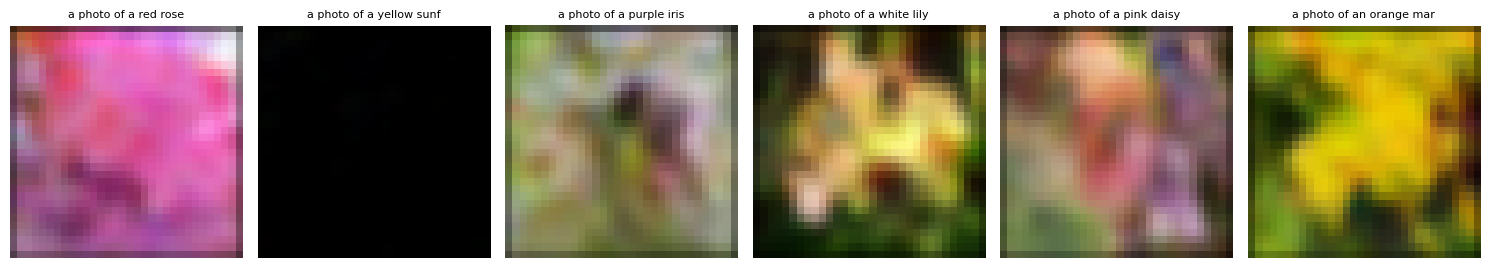

In [21]:
prompts = [
    "a photo of a red rose",
    "a photo of a yellow sunflower",
    "a photo of a purple iris",
    "a photo of a white lily",
    "a photo of a pink daisy",
    "a photo of an orange marigold",
]
signals, images = generate_from_prompts(
    model, renderer, clip_model, prompts,
    n_steps=SEQ_LEN, temperature=0.9, top_p=0.95,
)
show_grid(prompts, images, path="generations.png")

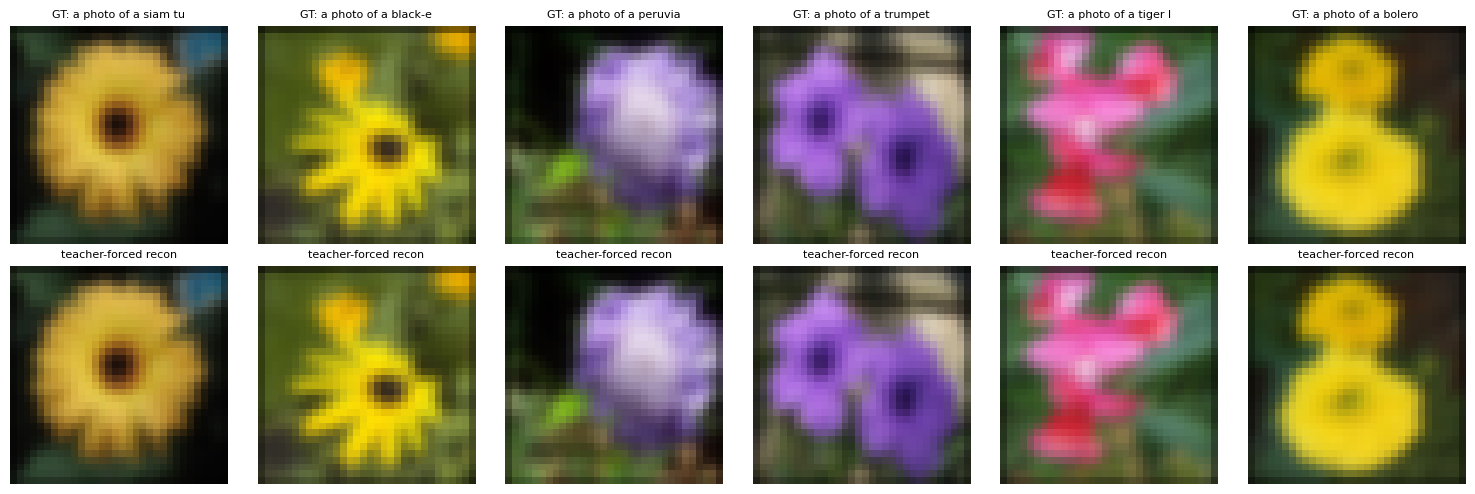

In [22]:
@torch.no_grad()
def visualize_teacher_forced(model, renderer, clip_model, dataset, n=6):
    """
    Row 0: ground-truth images rendered from dataset signals.
    Row 1: teacher-forced reconstructions (model predicts each step given GT context).

    If row 1 looks good but AR generation (above) looks noisy, the problem is
    exposure bias in the autoregressive rollout, not model capacity.
    If row 1 is also noisy/wrong-color, the model itself needs more training.
    """
    model.eval()
    idxs = np.random.choice(len(dataset), n, replace=False)
    signals = torch.stack([dataset[i][0] for i in idxs]).to(cfg.device)
    captions = [dataset[i][1] for i in idxs]

    gt_images = renderer(signals).cpu()

    clip_emb = encode_texts(clip_model, captions, cfg.device)
    b, seq_n, c = signals.shape
    shifted = torch.cat(
        [torch.zeros(b, 1, c, device=cfg.device), signals[:, :-1, :]], dim=1
    )
    params = model(shifted, clip_emb)
    pred = model.head.sample(params, temperature=0.0)
    recon_images = renderer(pred).cpu()

    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5))
    for i in range(n):
        axes[0, i].imshow(gt_images[i].permute(1, 2, 0).clamp(0, 1).numpy())
        axes[0, i].set_title(f"GT: {captions[i][:20]}", fontsize=8)
        axes[0, i].axis("off")
        axes[1, i].imshow(recon_images[i].permute(1, 2, 0).clamp(0, 1).numpy())
        axes[1, i].set_title("teacher-forced recon", fontsize=8)
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.savefig("teacher_forced.png", dpi=120, bbox_inches="tight")
    plt.show()


visualize_teacher_forced(model, renderer, clip_model, dataset)

## 16. Evaluation

Two numbers to report, both on the held-out test split (never seen during training):

- **bpd_pixel** (bits per sub-pixel). Computed as `NLL_per_image / log(2) / (H*W*C)`,
  which matches the PixelCNN++ and iGPT reporting convention and makes cross-paper
  comparison valid. Do not use `bpd_signal` (per active signal sample) for comparisons
  -- it is not on the same scale as pixel-space models.
- **PSNR (teacher-forced)**. One-step greedy reconstruction given ground-truth context.
  Isolates model fit from exposure bias: if PSNR is high but AR generation looks bad,
  the problem is the autoregressive rollout, not the model capacity.

For a full paper, add FID against 10k generated samples. FID requires a separate
InceptionV3 feature model and is not included here.

In [23]:
# Evaluate on held-out test set (not training data)
print("test:", evaluate(model, clip_model, test_dataset, n_batches=20))

test: {'nll_per_image_nats': 14892.708463541667, 'bpd_pixel': 6.994022345623912, 'bpd_signal': 3.497011172811956, 'psnr_db': 31.779750480556462}
